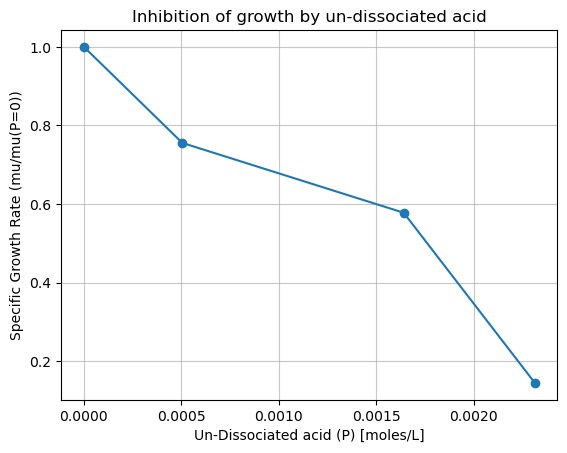

Inhibition constant K_I: 0.0004 moles/L


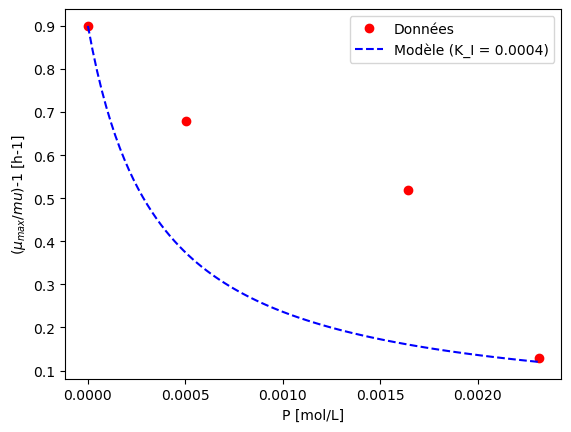

Inhibition constant P_max: 0.0031 moles/L
R² for Monod inhibition model: 0.2920
R² for linear inhibition model: 0.9206


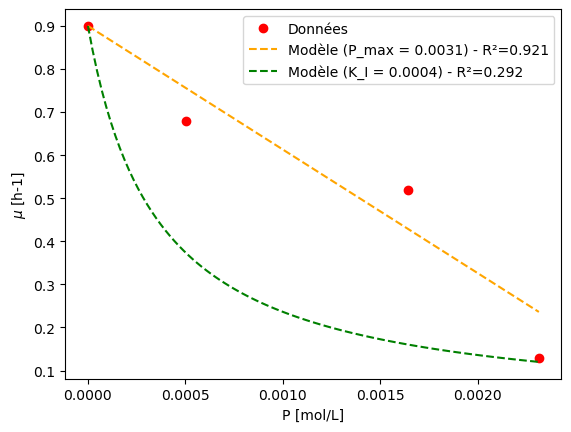

Pour 1 g/L, la croissance s'arrête à pH = 4.29
Pour 10 g/L, la croissance s'arrête à pH = 5.42


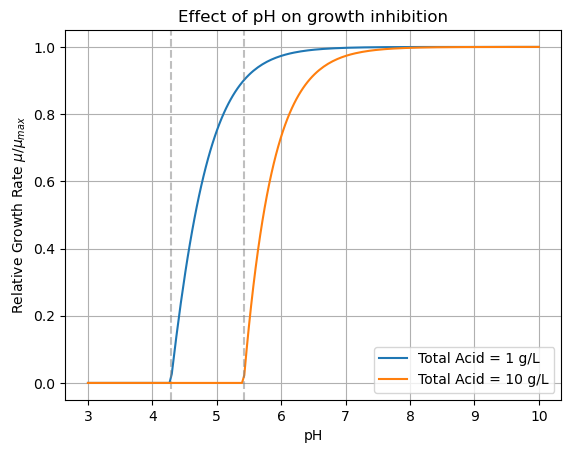

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##exo a)

#données  
p__total_gL=np.array([0,12,39,55])
mu=np.array([0.9,0.68,0.52,0.13])
pH=6.3
pKa=3.88
M=90.08

#Concentration en moles/L
p_total_M = p__total_gL/M 

#Concentration en acide non dissocié en moles/L
p_nd_M = p_total_M/(1+10**(pH-pKa))

#Calcul du taux de croissance spécifique normalisé
mu_spec=mu/mu[0]

#plot
plt.plot(p_nd_M, mu_spec, marker='o', linestyle='-')
plt.xlabel('Un-Dissociated acid (P) [moles/L]')
plt.ylabel('Specific Growth Rate (mu/mu(P=0))')
plt.title('Inhibition of growth by un-dissociated acid')
plt.grid(True, alpha=0.7)
plt.show()

##exo b)

#Données
mu_max = mu[0]

#Linéarisation de la relation de Monod
x_fit = p_nd_M[1:]
y_fit = (mu_max/mu[1:]) - 1

#polyfit
pente, intercept = np.polyfit(x_fit, y_fit, 1)

#Extraction de K_I
K_I = 1/pente
print(f'Inhibition constant K_I: {K_I:.4f} moles/L')

#plot pour voir la linéarisation
p_model_b = np.linspace(0, max(p_nd_M), 100)
mu_model_b = mu_max / (1 + p_model_b / K_I)

#Plot
plt.plot(p_nd_M, mu, 'ro', label='Données')
plt.plot(p_model_b, mu_model_b, 'b--', label=f'Modèle (K_I = {K_I:.4f})')
plt.xlabel('P [mol/L]')
plt.ylabel('($\mu_{max}/mu$)-1 [h-1]')
plt.legend()
plt.show()

##exo c)

#Données
mu_max = mu[0]

#Linéarisation de la relation de Monod
x_fit = p_nd_M[1:]
y_fit = 1-(mu[1:]/mu_max) 

#polyfit
pente_c, intercept_c = np.polyfit(x_fit, y_fit, 1)

#Extraction de K_I
P_max = 1/pente_c
print(f'Inhibition constant P_max: {P_max:.4f} moles/L')

#plot pour voir la linéarisation
p_model_c = np.linspace(0, max(p_nd_M), 100)
mu_model_c = mu_max * (1 - p_model_c / P_max)

# 4. Calcul du R² pour comparer (mesure quantitative)
def get_r2(y_true, y_pred):
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

r2_b = get_r2(mu, mu_max / (1 + p_nd_M / K_I))
r2_c = get_r2(mu, mu_max * (1 - p_nd_M / P_max))
print(f'R² for Monod inhibition model: {r2_b:.4f}')
print(f'R² for linear inhibition model: {r2_c:.4f}')

#Plot
plt.plot(p_nd_M, mu, 'ro', label='Données')
plt.plot(p_model_c, mu_model_c, '--', label=f'Modèle (P_max = {P_max:.4f}) - R²={r2_c:.3f}', color='orange')
plt.plot(p_model_b, mu_model_b, '--', label=f'Modèle (K_I = {K_I:.4f}) - R²={r2_b:.3f}', color='green')
plt.xlabel('P [mol/L]')
plt.ylabel('$\mu$ [h-1]')
plt.legend()
plt.show()


#exo d)

#Données
pK_a =  3.88
M = 90.08
P_total = [1, 10] # g/L
pH_r = np.linspace(3, 10, 200)

for pt in P_total:
    # 1. Calcul de P en mol/L pour chaque pH
    P_at_pH = (pt / M) / (1 + 10**(pH_r - pK_a))
    
    # 2. Calcul du taux relatif (modèle linéaire)
    # On utilise np.maximum(..., 0) pour ne pas avoir de taux négatifs
    relative_mu_pH = np.maximum(1 - (P_at_pH / P_max), 0)
    
    plt.plot(pH_r, relative_mu_pH, label=f'Total Acid = {pt} g/L')

    # 3. Calcul du pH critique (où mu = 0)
    # On résout : 1 + 10^(pH-pKa) = (P_total/M) / P_max
    ratio = (pt / M) / P_max
    if ratio > 1:
        pH_stop = pK_a + np.log10(ratio - 1)
        print(f"Pour {pt} g/L, la croissance s'arrête à pH = {pH_stop:.2f}")
        plt.axvline(pH_stop, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('pH')
plt.ylabel('Relative Growth Rate $\mu/\mu_{max}$')
plt.title('Effect of pH on growth inhibition')
plt.legend()
plt.grid(True)
plt.show()

 